#### ตัวอย่างการใช้งาน Linear Regression ในการสร้างโมเดลเพื่อทำนาย

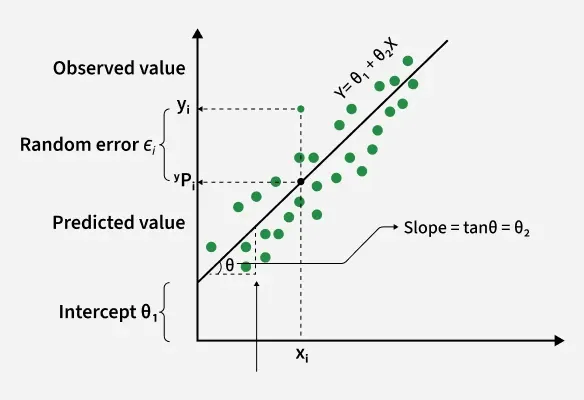

Linear Regression เป็นพื้นฐานที่สำคัญสำหรับการเรียนรู้เรื่องของ Statistics Learning หรือ Machine Learning

ทบทวน Linear Regression มีสมการสำคัญคือ $\hat{y_i}=\theta_0+\theta_1x$
เมื่อ $\theta_0$ คือ จุดตัดแกน Y ของโมเดล $\theta_1$ คือ ความชันของโมเดล

โดย Dataset ที่เราได้มีการเอามาใช้งาน แหล่งอ้างอิง https://www.geeksforgeeks.org/machine-learning/dataset-for-linear-regression/

เป็นข้อมูลที่เกี่ยวข้องกับการใช้เชื้อเพลิงน้ำมันของรถยนต์ โดย Goals ของการสร้าง model นี้คือ เราต้องการจะทำนายว่าแรงม้าของรถยนต์ส่งผลต่อการกินพลังงานน้ำมันในหน่วย ไมล์ต่อแกลลอนไหม ด้วยการใช้งาน Linear Regression

In [ ]:
"""
    เริ่มต้นจากการ Download เครื่องมือสำคัญที่จำเป็น ได้แก่
    1. numpy สำหรับการคำนวณสำคัญ
    2. matplotlib สำหรับการพล็อตกราฟ
    3. pandas สำหรับการจัดการไฟล์
    4. scikit-learn สำหรับการสร้างโมเดล machine learning
"""
%pip install numpy matplotlib pandas
%pip install -U scikit-learn

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.linear_model import LinearRegression

#1. ทำการตรวจสอบ Dataset ของเราก่อนว่าข้อมูลที่เราสนใจมีข้อผิดพลาดหรือไม่ ?
nameData = "dataset_linear_regression.csv"
dataset = pd.read_csv(nameData)
print("แสดงผลข้อมูลใน 5 บรรทัดแรก")
print(dataset.head())

#ตรวจสอบประเภทของข้อมูลที่สนใจว่าเป็นข้อมูลประเภทเดียวกันไหม ?
print("ตรวจสอบประเภทของข้อมูล")
print(dataset.info())


พบว่าที่ horsepower ของเราเป็นประเภทข้อมูลแบบ object หมายความว่า ข้อมูลของเราอาจจะมีได้หลายประเภท ดังนั้น สิ่งที่เราจะต้องทำคือ เปลี่ยนข้อมูลของเราที่ไม่ใช่ตัวเลขเป็น NaN จากนั้นทำการคัดออก

In [30]:
#ขั้นตอน 2 การเตรียมข้อมูล จัดการประเภทของข้อมูลให้ตรงกัน !
df = pd.read_csv(nameData)

#ทำการเลือก Column "horsepower" จากนั้นทำการเปลี่ยนประเภทของข้อมูลนี้เป็นตัวเลข 
#หากไม่สามารถเปลี่ยนได้จะทำการ Return ออกมาเป็น NaN แทน
df['horsepower'] = pd.to_numeric(df['horsepower'], errors='coerce')
print(df.info())

df = df.dropna(subset=['horsepower'])

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    392 non-null    float64
 4   weight        398 non-null    int64  
 5   acceleration  398 non-null    float64
 6   model year    398 non-null    int64  
 7   origin        398 non-null    int64  
 8   car name      398 non-null    object 
dtypes: float64(4), int64(4), object(1)
memory usage: 28.1+ KB
None


In [ ]:
from sklearn.model_selection import train_test_split
X = df[['horsepower']]    #สร้างตัวแปรสำหรับการเก็บ Features ตัวแปรไม่อิสระ
Y = df['mpg']           #สร้างตัวแปรสำหรับการเก็บ Features ตัวแปรอิสระ

#ทำการแบ่งข้อมูลของเราออกเป็น 2 กลุ่ม คือ Train_set และ Test_set
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

In [32]:
model = LinearRegression()
model.fit(X_train, Y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [33]:
from sklearn.metrics import mean_squared_error, r2_score 

#สร้างคำสั่งสำหรับการทำนายโมเดลจากข้อมูลทดสอบ
y_pred = model.predict(X_test)

#คำนวณความแม่นยำด้วย MSE, R^2 Errors
mse = mean_squared_error(Y_test, y_pred)
r2 = r2_score(Y_test, y_pred)

print(f"Mean Squared Error : {mse}")
print(f"R-squared Error : {r2}")

Mean Squared Error : 22.153237123863413
R-squared Error : 0.5659681822256185


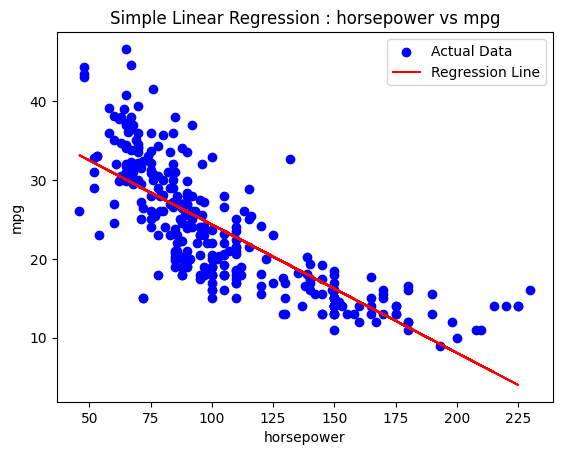

In [34]:
plt.scatter(X_train, Y_train, color='blue',label='Actual Data')
plt.plot(X_test, y_pred, color='red', label="Regression Line")
plt.xlabel('horsepower')
plt.ylabel('mpg')
plt.title('Simple Linear Regression : horsepower vs mpg')
plt.legend()
plt.savefig('results.png')

สามารถสรุปผลได้ว่า "ยิ่งกำลังแรงม้าของเครื่องยนต์มีค่ามากขึ้น อัตราการกินพลังงานก็จะลดลง"